# Experiment 7 — Dataset Size and Learning Efficiency

This notebook investigates how different machine learning models respond to varying dataset sizes.

The purpose of the experiment is to examine whether preprocessing and feature engineering can compensate for limited training data and whether different inductive biases exhibit different levels of data efficiency.

The experiment compares:
- Raw preprocessing
- Cleaned preprocessing
- Engineered preprocessing

under varying dataset size conditions.

Personally, I find dataset size particularly interesting because model complexity is often discussed together with data availability. Flexible neural architectures are frequently assumed to require substantially larger datasets in order to realize their representational advantages, while simpler classical models may perform comparatively well under smaller data conditions. This experiment attempts to investigate that relationship more systematically.

## Project Path Configuration

The notebook explicitly adds the project root directory to the Python path in order to ensure that the centralized experimental framework within the `src/` directory can be imported consistently across notebooks.

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

## Importing the Experimental Framework

The notebook imports the centralized modules responsible for dataset loading, experiment execution, visualization, and result saving.

In [2]:
from src.data.load_data import (
    load_adult_dataset
)

from src.experiments.dataset_size import (
    run_dataset_size_experiment
)

from src.visualization.plots import (
    plot_f1_comparison
)

from src.visualization.summaries import (
    save_summary_table
)

from src.utils.saving import (
    save_metrics
)

## Dataset Loading

The Adult Income dataset is loaded through the centralized data-loading module in order to ensure consistency across experiments.

In [3]:
X, y = load_adult_dataset()

## Dataset Size Configurations

The experiment evaluates multiple dataset size conditions in order to investigate learning efficiency under varying levels of data availability.

Three dataset sizes are examined:
- Small dataset
- Medium dataset
- Large dataset

This setup allows the analysis to investigate how preprocessing effectiveness and model complexity interact with training data availability.

In [4]:
import pandas as pd

dataset_configs = {
    "Small Dataset": 0.25,
    "Medium Dataset": 0.5,
    "Large Dataset": 1.0
}

all_results = []

for config_name, dataset_fraction in dataset_configs.items():
    
    print(f"\nRunning configuration: {config_name}")
    
    temp_results = run_dataset_size_experiment(
        X,
        y,
        dataset_fraction=dataset_fraction
    )
    
    temp_results["dataset_size"] = config_name
    
    all_results.append(temp_results)

results_df = pd.concat(
    all_results,
    ignore_index=True
)

results_df


Running configuration: Small Dataset

=== Raw Preprocessing ===
Training Logistic Regression...


Training Decision Tree...
Training Naive Bayes...
Training MLP...



=== Cleaned Preprocessing ===
Training Logistic Regression...


Training Decision Tree...
Training Naive Bayes...
Training MLP...



=== Engineered Preprocessing ===
Training Logistic Regression...


...


=== Engineered Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...


Training MLP...


,preprocessing,model,accuracy,f1_score,roc_auc,dataset_size
0,Raw,Logistic Regression,0.786650,0.417877,0.637258,Small Dataset
1,Raw,Decision Tree,0.798526,0.589316,0.731989,Small Dataset
2,Raw,Naive Bayes,0.800573,0.433062,0.838476,Small Dataset
3,Raw,MLP,0.780508,0.441667,0.675513,Small Dataset
4,Cleaned,Logistic Regression,0.801392,0.671632,0.904064,Small Dataset
5,Cleaned,Decision Tree,0.799345,0.590301,0.732527,Small Dataset
6,Cleaned,Naive Bayes,0.421376,0.445230,0.699723,Small Dataset
7,Cleaned,MLP,0.824324,0.622026,0.866705,Small Dataset
8,Engineered,Logistic Regression,0.796888,0.664411,0.899196,Small Dataset
9,Engineered,Decision Tree,0.815725,0.612069,0.770506,Small Dataset


## Saving Experimental Results

The experimental results are saved to the centralized results directory structure in order to support reproducibility and later cross-experiment analysis.

In [5]:
save_metrics(
    results_df,
    "dataset_size_results.csv"
)

Metrics saved to: ../results/metrics/dataset_size_results.csv


## Dataset Size Visualization

The following figure compares model performance across preprocessing levels under limited-data conditions.

Plot saved to: ../results/plots/dataset_size_f1_comparison.png


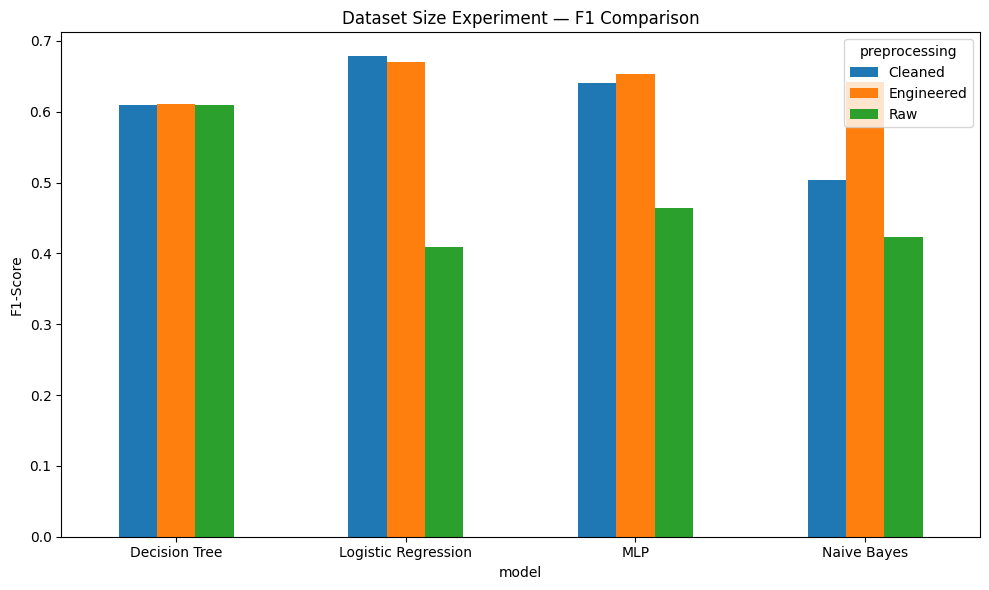

In [6]:
plot_f1_comparison(
    results_df,
    title="Dataset Size Experiment — F1 Comparison",
    filename="dataset_size_f1_comparison.png"
)

## Summary Table

A summary table is generated in order to support later cross-experiment comparison and thesis reporting.

In [7]:
summary_table = save_summary_table(
    results_df,
    metric="f1_score",
    filename="dataset_size_summary_table.csv"
)

summary_table

Table saved to: ../results/tables/dataset_size_summary_table.csv


,model,preprocessing,f1_score
0,Decision Tree,Cleaned,0.608988
1,Decision Tree,Engineered,0.611421
2,Decision Tree,Raw,0.608886
3,Logistic Regression,Cleaned,0.678161
4,Logistic Regression,Engineered,0.670718
5,Logistic Regression,Raw,0.408943
6,MLP,Cleaned,0.640930
7,MLP,Engineered,0.652982
8,MLP,Raw,0.464360
9,Naive Bayes,Cleaned,0.503195


## Interpretation of Dataset Size Results

The dataset size experiment reveals substantial differences in how models respond to limited training data availability.

One of the clearest findings is that preprocessing quality strongly influences predictive robustness under reduced-data conditions. Raw preprocessing frequently produces substantial performance degradation, while cleaned and engineered preprocessing improve learning efficiency considerably.

Logistic Regression demonstrates relatively strong robustness under limited-data conditions once preprocessing quality improves. Under raw preprocessing, predictive performance deteriorates substantially, while cleaned preprocessing restores much of the lost performance. This suggests that simpler linear models may benefit strongly from stable and well-structured representations when training data becomes limited.

The Multi-Layer Perceptron (MLP) demonstrates an especially interesting pattern. Despite its greater representational flexibility, performance under raw preprocessing conditions deteriorates considerably when the available dataset becomes smaller. Engineered preprocessing substantially improves predictive quality, suggesting that refined representations may partially compensate for limited training data even in more complex models.

Naive Bayes again demonstrates notable improvement under engineered preprocessing conditions. One possible interpretation is that feature refinement reduces noisy or unstable dependencies and allows the model to generalize more effectively despite reduced data availability.

Decision Trees remain comparatively stable across preprocessing levels, although their overall predictive performance remains slightly below the strongest-performing models. This relative stability may indicate moderate robustness to limited-data conditions.

Personally, I found it particularly interesting how strongly preprocessing quality appeared to influence learning efficiency. In several cases, representation refinement seemed to compensate for a substantial portion of the degradation introduced through reduced training data itself.

Overall, the results increasingly support the broader motivation of the project: representation quality and inductive bias alignment may play a central role in determining predictive performance under constrained data conditions, sometimes reducing the need for substantially larger datasets or more complex models.